# import liabries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


# dataset


In [2]:
np.random.seed(42)

rows = 1000

df = pd.DataFrame({
    "Employee_ID": np.arange(1, rows + 1),
    "Age": np.random.randint(21, 60, rows),
    "Gender": np.random.choice(["Male", "Female"], rows),
    "Education": np.random.choice(
        ["Bachelor", "Master", "PhD"],
        rows
    ),
    "Experience": np.random.randint(0, 30, rows),
    "Job_Role": np.random.choice(
        ["Software Engineer",
         "Data Analyst",
         "Manager",
         "HR",
         "Tester"],
        rows
    ),
    "City": np.random.choice(
        ["Hyderabad",
         "Bangalore",
         "Chennai",
         "Pune"],
        rows)
})

df["Salary"] = (
    300000
    + df["Experience"] * 50000
    + df["Age"] * 5000
    + np.random.randint(-50000, 50000, rows)
)

df.head()

,Employee_ID,Age,Gender,Education,Experience,Job_Role,City,Salary
0,1,59,Female,PhD,27,Manager,Chennai,1981567
1,2,49,Male,PhD,13,Software Engineer,Chennai,1236748
2,3,35,Male,Master,23,HR,Pune,1650886
3,4,28,Female,Master,9,Software Engineer,Chennai,858816
4,5,41,Male,Master,15,Tester,Bangalore,1290824


In [3]:
df.to_csv("data/employee_salary.csv", index=False)

print("Dataset Saved Successfully!")

Dataset Saved Successfully!


In [4]:
df = pd.read_csv("data/employee_salary.csv")

df.head()


,Employee_ID,Age,Gender,Education,Experience,Job_Role,City,Salary
0,1,59,Female,PhD,27,Manager,Chennai,1981567
1,2,49,Male,PhD,13,Software Engineer,Chennai,1236748
2,3,35,Male,Master,23,HR,Pune,1650886
3,4,28,Female,Master,9,Software Engineer,Chennai,858816
4,5,41,Male,Master,15,Tester,Bangalore,1290824


# dataset information

In [5]:
print(df.shape)

df.info()

(1000, 8)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Employee_ID  1000 non-null   int64
 1   Age          1000 non-null   int64
 2   Gender       1000 non-null   str  
 3   Education    1000 non-null   str  
 4   Experience   1000 non-null   int64
 5   Job_Role     1000 non-null   str  
 6   City         1000 non-null   str  
 7   Salary       1000 non-null   int64
dtypes: int64(4), str(4)
memory usage: 62.6 KB


# missing values

In [6]:
df.isnull().sum()

Employee_ID    0
Age            0
Gender         0
Education      0
Experience     0
Job_Role       0
City           0
Salary         0
dtype: int64

# statical summary

In [7]:
df.describe()

,Employee_ID,Age,Experience,Salary
count,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,500.500000,40.445000,14.622000,1.233861e+06
std,288.819436,11.499183,8.654711,4.421772e+05
min,1.000000,21.000000,0.000000,3.950090e+05
25%,250.750000,30.000000,7.000000,8.612382e+05
50%,500.500000,41.000000,15.000000,1.255568e+06
75%,750.250000,50.000000,22.000000,1.604410e+06
max,1000.000000,59.000000,29.000000,2.064245e+06


# encode categorical columns

In [8]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Gender"] = encoder.fit_transform(df["Gender"])
df["Education"] = encoder.fit_transform(df["Education"])
df["Job_Role"] = encoder.fit_transform(df["Job_Role"])
df["City"] = encoder.fit_transform(df["City"])

df.head()

,Employee_ID,Age,Gender,Education,Experience,Job_Role,City,Salary
0,1,59,0,2,27,2,1,1981567
1,2,49,1,2,13,3,1,1236748
2,3,35,1,1,23,1,3,1650886
3,4,28,0,1,9,3,1,858816
4,5,41,1,1,15,4,0,1290824


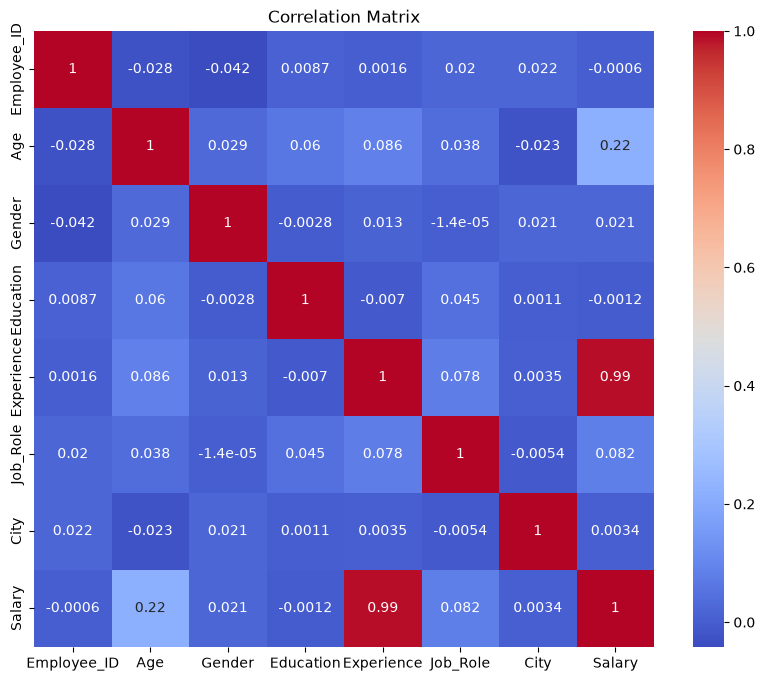

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [10]:
X = df.drop("Salary", axis=1)
y = df["Salary"]

print(X.head())

   Employee_ID  Age  Gender  Education  Experience  Job_Role  City
0            1   59       0          2          27         2     1
1            2   49       1          2          13         3     1
2            3   35       1          1          23         1     3
3            4   28       0          1           9         3     1
4            5   41       1          1          15         4     0


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(800, 7)
(200, 7)


In [12]:
model = LinearRegression()

In [13]:
model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [14]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[ 934789.33990948  537800.33949829  603290.34204242 1072833.80029314
 1571649.50108451 1923699.53582854 1302542.9853703  1141168.74081891
 1990027.08834506 1064584.06491164]


In [15]:
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("R2 Score :", r2_score(y_test, y_pred))

MAE : 24469.199953012372
MSE : 799105471.8668958
R2 Score : 0.9959051445557375


In [16]:
import os

os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/employee_salary_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [17]:
results = pd.DataFrame({
    "Actual Salary": y_test,
    "Predicted Salary": y_pred
})

results.head()

,Actual Salary,Predicted Salary
521,984572,9.347893e+05
737,546816,5.378003e+05
740,621972,6.032903e+05
660,1115477,1.072834e+06
411,1582559,1.571650e+06


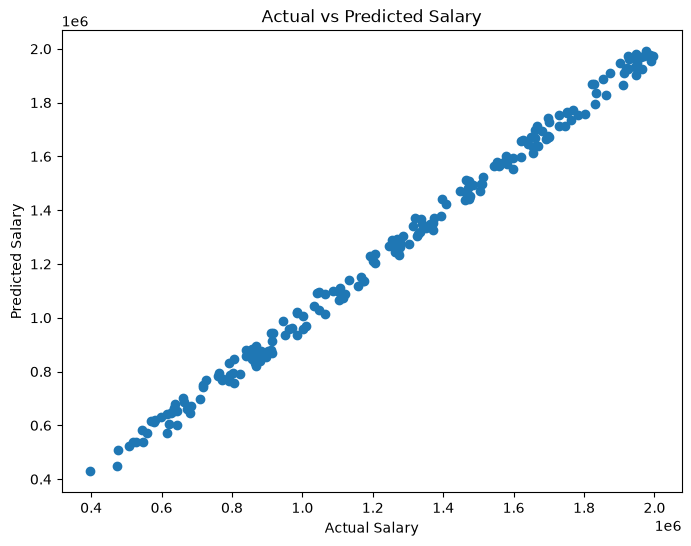

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")

plt.title("Actual vs Predicted Salary")

plt.show()

In [19]:
sample = X.iloc[[0]]

prediction = model.predict(sample)

print("Predicted Salary:", prediction[0])

Predicted Salary: 1942807.3254556418


In [20]:
print("=" * 50)
print("EMPLOYEE SALARY PREDICTION PROJECT COMPLETED")
print("=" * 50)

EMPLOYEE SALARY PREDICTION PROJECT COMPLETED


In [21]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/employee_salary_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [22]:
import os

print(os.getcwd())
print(os.path.exists("models"))
print(os.listdir("models"))

c:\Users\vishn\OneDrive\Desktop\ML-projects\Employee-Salary-Prediction
True
['employee_salary_model.pkl']
